## **Importar paquetes/bibliotecas**
Aquí "llamamos" a las bibliotecas.

- **[Matplotlib](https://matplotlib.org/):** Sirve para dibujar gráficas y visualizaciones.
- **[NumPy](https://numpy.org/):** Es una biblioteca para matemáticas avanzadas y manejo de números.
- **[Pandas](https://pandas.pydata.org/):** Sirve para manejar tablas de datos, como si fuera un Excel programable.
- De la biblioteca científica **[SciPy](https://scipy.org/)** se trae una herramienta para estadística.
- De la biblioteca de aprendizaje automático [scikit-learn](https://scikit-learn.org), se traen herramientas específicas:
  - [Métricas](https://scikit-learn.org/stable/api/sklearn.metrics.html) para saber qué tan bien aprendió el modelo: $R^2$ ([`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)) y MSE ([`mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)).
  - Una herramienta para dividir los datos de entrenamiento, prueba y verificación ([`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)) de [`model_selection`](https://scikit-learn.org/stable/api/sklearn.model_selection.html)
  - El modelo de inteligencia artificial ([`neural_network`](https://scikit-learn.org/stable/api/sklearn.neural_network.html)) llamado [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier) (*Multi-layer Perceptron Classifier*).
  - Una herramienta para escalar los números ([`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)) y hacerlos más fáciles de procesar a través de [preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html).

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

In [4]:
# 1. CARGAR DATOS
# Se lee el archivo CSV y se convierte en un DataFrame (tabla).
# 'df' será la variable que contiene toda la hoja de cálculo.
df = pd.read_csv('../../data/ann_and_pso_data.csv')
# Inspección visual: Mostramos las primeras 5 filas para verificar que los datos 
# se cargaron con el formato correcto (encabezados, separadores, etc.).
df.head()

,Experiment no.,Nozzle temperature (C°),Layer height (μm),Print speed (mm/s),Nozzle diameter (mm),Infill density (%),Test1: surface roughness (µm),Test2: surface roughness (µm),Standard deviation
0,1,210,200,30,0.3,30,42.7,43.1,0.28
1,2,190,150,75,0.4,20,26.2,26.4,0.14
2,3,190,200,30,0.5,10,54.0,54.2,0.14
3,4,200,200,75,0.4,20,30.5,30.5,0.00
4,5,190,100,120,0.5,10,25.0,25.2,0.14


## **Red Neuronal**

In [5]:
# 2. PREPARAR DATOS (Manipulación de Matrices)

# Extracción de Variables Independientes (X):
# Se seleccionan las columnas de la 1 a 5 que contienen los parámetros físicos.
# '.values' convierte la tabla en una matriz numérica pura (sin encabezados) para cálculo matemático.
# 5 datos de entradas:
# - Nozzle temperature (C°),
# - Layer height (μm),
# - Print speed (mm/s)
# - Nozzle diameter (mm)
# - Infill density (%)
X_raw = df.iloc[:, 1:6].values

# Extracción de Variables Dependientes (Y):
# Se separan los resultados del experimento.
# Hay dos pruebas distintas (Test1: surface roughness (µm) y Test2: surface roughness (µm))
y_test1 = df.iloc[:, 6].values
y_test2 = df.iloc[:, 7].values

# REESTRUCTURACIÓN:
# Se tiene 1 conjunto de entradas que produjo 2 resultados distintos (Test1 y Test2).
# Para que la Red Neuronal tenga más ejemplos de donde aprender, se apilan los datos.
# Se concatena verticalmente las entradas (X sobre X) y las salidas (Test1 sobre Test2).
X = np.concatenate([X_raw, X_raw], axis=0)
y = np.concatenate([y_test1, y_test2], axis=0)

In [6]:
# 3. ESCALAR (Normalización Min-Max)
# Si se mezcla Temperatura (ej. 200°C) con Densidad (ej. 0.05), la red neuronal le dará
# injustamente más importancia a la Temperatura solo porque el número es mayor.

# Se crean objetos que transformarán todos los datos al rango [0, 1].
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Se calculan los máximos y mínimos de la matriz X y se transforma.
# Ahora todas las variables de entrada valen entre 0 y 1.
X_scaled = scaler_X.fit_transform(X)

# Se hace lo mismo para el vector Y.
# Nota: '.reshape(-1, 1)' convierte el vector en una columna vertical para que la 
# fórmula matricial funcione correctamente.
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

In [7]:
# 4. DIVISIÓN DE DATOS (Validación Cruzada tipo Hold-Out)
# El paper usa 70% Train, 15% Test, 15% Validation

# Definimos una semilla. Esto asegura que la aleatoriedad sea determinista (repetibilidad).
# Es decir, si se corre este código, se obtendrá exactamente la misma división de datos.
seed = 419

# Paso 1: Se separa el 70% para entrenar (Train) y se guarda el 30% restante en una variable temporal (temp).
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.30, random_state=seed)

# Paso 2: Ese 30% temporal se parte a la mitad (0.50).
# Esto deja un 15% para validación (Val) y 15% para comprobación final (Test).
# - Train: Para que la IA estudie.
# - Val: Para se ajusten los parámetros mientras se aprende.
# - Test: Para la comprobación final con datos que la IA nunca ha visto.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=seed)

In [8]:
# 5. MODELADO (Configuración de la Red Neuronal replicando la arquitectura 7-4-1 y Levenberg-Marquardt)
# Se instancia el modelo de Regresión Perceptrón Multicapa (MLP)
# Estructura exacta del paper son dos capas ocultas de 7 y 4 neuronas respectivamente.
# La función de activación es 'tanh': Equivalente a Tan-sigmoid 
# Le optimizador es el de 'lbfgs': Aproximación a Levenberg-Marquardt para datasets pequeños
model = MLPRegressor(
    # Topología de la red: Dos capas ocultas de procesamiento, la primera con 7 neuronas y la segunda con 4
    hidden_layer_sizes=(7, 4),
    # Función de Activación 'tanh' (Tangente Hiperbólica):
    # Define cómo las neuronas transmiten la señal
    # Tanh es ideal para centrar los datos en 0
    activation='tanh',
    # Solver 'lbfgs' (Algoritmo de Optimización):
    # Es el método matemático que ajusta los pesos para reducir el error
    # 'lbfgs' es un método Quasi-Newton, mucho más preciso y rápido que el estándar para datasets pequeños (<1000 datos)
    solver='lbfgs',
    # Máximo de iteraciones: Cuantas veces el algoritmo revisar los datos para intentar mejorar
    max_iter=15,
    # Alpha (Regularización): Una penalización matemática para evitar que el modelo se vuelva
    # demasiado complejo y memorice los datos (Overfitting).
    alpha=0.001,
    # Se fija la semilla aleatoria nuevamente para reproducibilidad científica
    random_state=seed
)

In [9]:
# 6. Entrenar

# Este es el momento en que el algoritmo observa los datos de estudio (X_train) y sus respuestas correctas (y_train)
# Matemáticamente, aquí comienza un proceso iterativo de optimización. El algoritmo ajusta los pesos internos de la
# red neuronal repetidamente para minimizar el error entre lo que él cree que es la respuesta y la respuesta real o
# esperada. Es la búsqueda del mínimo global en la superficie de error.
model.fit(X_train, y_train)

C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=15).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,loss,'squared_error'
,hidden_layer_sizes,"(7, ...)"
,activation,'tanh'
,solver,'lbfgs'
,alpha,0.001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,15
,shuffle,True


In [10]:
# 7. EVALUACIÓN
# Se usa el modelo ya entrenado para generar predicciones en tres escenarios distintos:

# 1. pred_train: Predice sobre los datos que ya estudió 
#    (Sirve para ver si aprendió bien)
pred_train = model.predict(X_train)
# 2. pred_test: Predice sobre datos nuevos que nunca ha visto
#    (Sirve para ver si es capaz de generalizar su conocimiento a situaciones nuevas)
pred_test = model.predict(X_test)
# 3. pred_all: Predice sobre todo el conjunto de datos original (escalado)
#    (Sirve para generar la gráfica global comparativa)
pred_all = model.predict(X_scaled)

In [11]:
# Des-escalar para ver errores reales en micras

# Se toman los datos reales (y_scaled) y se aplica la transformación inversa
# Esto devuelve los valores a su unidad física original
y_real = scaler_y.inverse_transform(y_scaled.reshape(-1, 1))
# Se hace lo mismo con las predicciones que hizo la máquina
# Se puede comparar en las unidades correctas.
pred_real = scaler_y.inverse_transform(pred_all.reshape(-1, 1))

# Cálculo del R2 Score (Coeficiente de Determinación):
# Mide la "Bondad de Ajuste". Dice qué porcentaje de la variabilidad de los datos 
# es capaz de explicar el modelo.
# - 1.00 = Modelo perfecto.
# - 0.00 = El modelo no predice nada útil.
print(f"R2 Score (Global): {r2_score(y_scaled, pred_all):.4f}")
# Cálculo del MSE (Error Cuadrático Medio):
# Mide el promedio de los errores al cuadrado
# Dice, en promedio, qué tan lejos está la predicción del valor real en unidades físicas
# Cuanto más bajo sea este número (cercano a 0), más preciso es el modelo.
print(f"MSE Global (Escala real): {mean_squared_error(y_real, pred_real):.4f}")

# El paper reporta un MSE de ~223.79 y R de ~0.97 
# Obtener un R2 cercano a 0.94-0.97 -> replicado el modelo exitosamente

R2 Score (Global): 0.9161
MSE Global (Escala real): 10.1750


## **Tabla comparativa 8**

In [12]:
# Columnas:
# - Nozzle temperature (C°),
# - Layer height (μm),
# - Print speed (mm/s)
# - Nozzle diameter (mm)
# - Infill density (%)
data_table_8 = np.array([
    [200.494, 100.0, 91.086, 0.3, 24.599, 12.382],
    [190.000, 100.0, 99.562, 0.3, 24.146, 10.874],
    [190.000, 100.0, 96.992, 0.3, 30.000, 12.022],
    [190.000, 100.0, 99.045, 0.3, 24.277, 10.872],
    [201.484, 100.0, 90.305, 0.3, 24.516, 12.389],
    [190.000, 100.0, 102.000, 0.3, 23.966, 10.953],
    [190.000, 100.0, 98.918, 0.3, 24.306, 10.873],
    [190.000, 100.0, 99.084, 0.3, 24.367, 10.871],
    [190.000, 100.0, 98.942, 0.3, 24.436, 10.872],
    [190.000, 100.0, 94.636, 0.3, 25.178, 11.082]
])

# Separar entradas (X) y el valor reportado por el paper (y_paper)
# Dividir la tabla manual: Las primeras 5 columnas son las condiciones del experimento,
# la última columna es el resultado esperado
X_validation = data_table_8[:, 0:5]
y_paper = data_table_8[:, 5]

# Concepto Clave: Consistencia Metrológica
# Se usa el comando "transform" y no "fit"
# Significa que se está usando la misma regla de medición (escalador) que se usó durante el entrenamiento
# No se recalculan los rangos, se miden estos nuevos datos con la vara que ya se calibró antes
X_val_scaled = scaler_X.transform(X_validation)
# La IA genera sus predicciones basándose en lo que aprendió
pred_scaled = model.predict(X_val_scaled)

# Se convierte la respuesta de la IA (que está en escala 0 a 1) a unidades reales (micras)
pred_my_model = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

# CONSTRUIR EL DATAFRAME
# Crear una tabla limpia con todas las columnas, incluyendo las predicciones del paper
columns = [
    "Nozzle temperature (°C)", 
    "Layer height (µm)", 
    "Print speed (mm/s)", 
    "Nozzle diameter (mm)", 
    "Infill density (%)",
    "Paper Prediction (µm)"
]

df_results = pd.DataFrame(data_table_8, columns=columns)

# Se agrega la columna con los resultados de la Red Neuronal (NN).
df_results["NN Prediction (µm)"] = pred_my_model

# CÁLCULO DE ERRORES:
# 1. Diferencia Absoluta (Diff)
df_results["Diff (µm)"] = abs(df_results["Paper Prediction (µm)"] - df_results["NN Prediction (µm)"])
# 2. Error Relativo (%)
df_results["Error relativo (%) respecto 11.9 µm"] = abs(11.9 - df_results["NN Prediction (µm)"]) / 11.9 * 100

# Se calcula el promedio de cada columna
# Esto es vital para ver si, en promedio, la IA tiene un sesgo (si tiende a predecir siempre más alto o más bajo)
# o si los errores se cancelan entre sí
avg_row = df_results.mean()
# Se convierte la serie a un DataFrame transpuesto para pegarlo abajo
df_avg = pd.DataFrame(avg_row).T
# Renombrar el índice a "Average"
df_avg.index = ["Average"]

# Concatenar y Visualizar:
# Se pega la fila de "Promedio" al final de la tabla
df_final = pd.concat([df_results, df_avg])

# Redondear a 3 decimales como en el paper
pd.set_option('display.precision', 3)

# Mostrar la tabla
print("Replicación de la Tabla 8 (Comparativa):")
display(df_final)

Replicación de la Tabla 8 (Comparativa):


,Nozzle temperature (°C),Layer height (µm),Print speed (mm/s),Nozzle diameter (mm),Infill density (%),Paper Prediction (µm),NN Prediction (µm),Diff (µm),Error relativo (%) respecto 11.9 µm
0,200.494,100.0,91.086,0.3,24.599,12.382,13.263,0.881,11.454
1,190.000,100.0,99.562,0.3,24.146,10.874,11.241,0.367,5.534
2,190.000,100.0,96.992,0.3,30.000,12.022,11.541,0.481,3.020
3,190.000,100.0,99.045,0.3,24.277,10.872,11.236,0.364,5.581
4,201.484,100.0,90.305,0.3,24.516,12.389,13.822,1.433,16.150
5,190.000,100.0,102.000,0.3,23.966,10.953,11.296,0.343,5.073
6,190.000,100.0,98.918,0.3,24.306,10.873,11.234,0.361,5.594
7,190.000,100.0,99.084,0.3,24.367,10.871,11.241,0.370,5.539
8,190.000,100.0,98.942,0.3,24.436,10.872,11.241,0.369,5.539
9,190.000,100.0,94.636,0.3,25.178,11.082,11.191,0.109,5.962


In [13]:
# Extraer la muestra promediada
## Excluir las columnas de predicción y diferencias
sample = df_final.iloc[-1:, :-4]
sample_scaled = scaler_X.transform(sample)
pred_scaled = model.predict(sample_scaled)
pred_real = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

print(f"Predicción para la muestra promediada: {pred_real[0]:.3f} µm")

Predicción para la muestra promediada: 11.166 µm


C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


In [14]:
# PREDICCIONES
pred_train_scaled = model.predict(X_train)
pred_val_scaled = model.predict(X_val)
pred_test_scaled = model.predict(X_test)
pred_all_scaled = model.predict(X_scaled)

# Invertir escala
y_train_real = scaler_y.inverse_transform(y_train.reshape(-1, 1)).ravel()
pred_train_real = scaler_y.inverse_transform(pred_train_scaled.reshape(-1, 1)).ravel()

y_val_real = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()
pred_val_real = scaler_y.inverse_transform(pred_val_scaled.reshape(-1, 1)).ravel()

y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
pred_test_real = scaler_y.inverse_transform(pred_test_scaled.reshape(-1, 1)).ravel()

y_all_real = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
pred_all_real = scaler_y.inverse_transform(pred_all_scaled.reshape(-1, 1)).ravel()

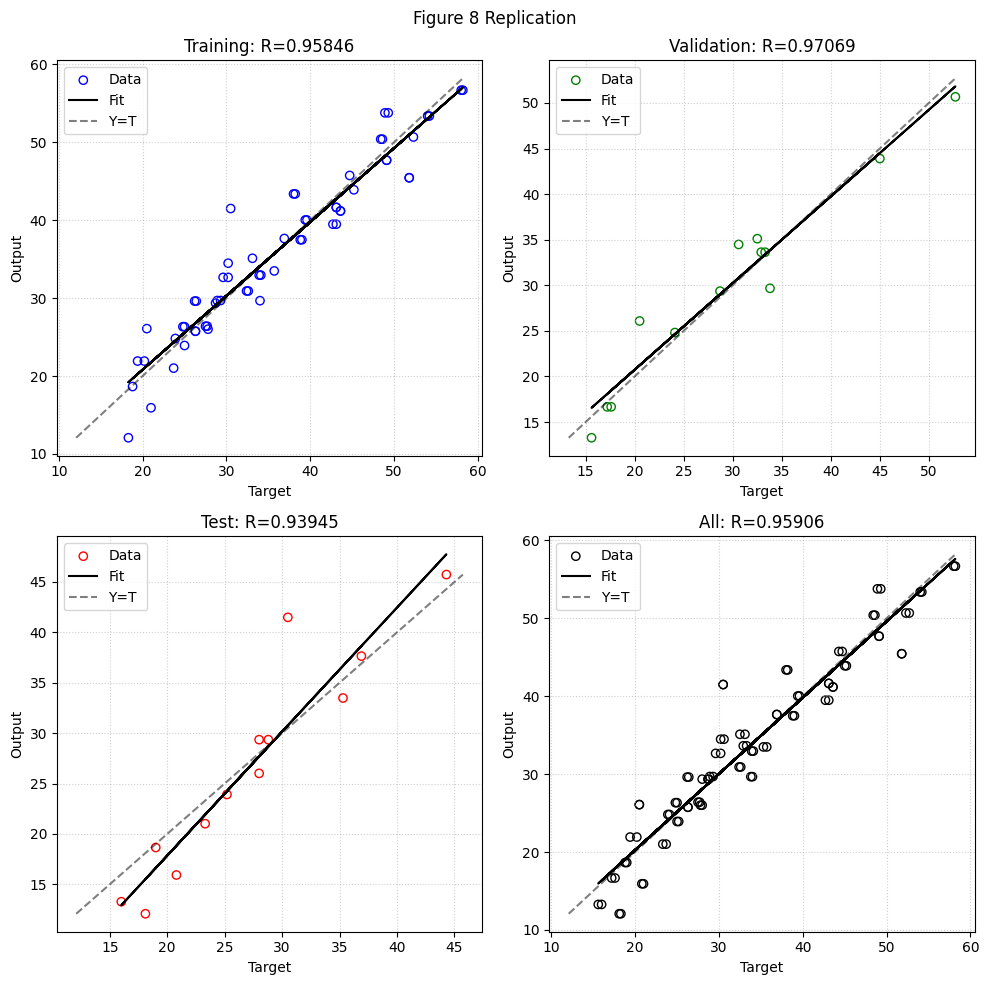

In [ ]:
# --- FIGURA 8: Regresiones ---
def plot_regression(ax, t, o, title, color):
    slope, intercept, r_value, _, _ = stats.linregress(t, o)
    ax.scatter(t, o, facecolors='none', edgecolors=color, label='Data')
    ax.plot(t, slope*t + intercept, 'k-', label='Fit')
    min_val = min(t.min(), o.min())
    max_val = max(t.max(), o.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Y=T')
    ax.set_title(f"{title}: R={r_value:.5f}")
    ax.set_xlabel('Target')
    ax.set_ylabel('Output')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

fig8, axs = plt.subplots(2, 2, figsize=(10, 10))
plot_regression(axs[0,0], y_train_real, pred_train_real, "Training", 'blue')
plot_regression(axs[0,1], y_val_real, pred_val_real, "Validation", 'green')
plot_regression(axs[1,0], y_test_real, pred_test_real, "Test", 'red')
plot_regression(axs[1,1], y_all_real, pred_all_real, "All", 'black')
plt.suptitle('Figure 8 Replication')
plt.tight_layout()

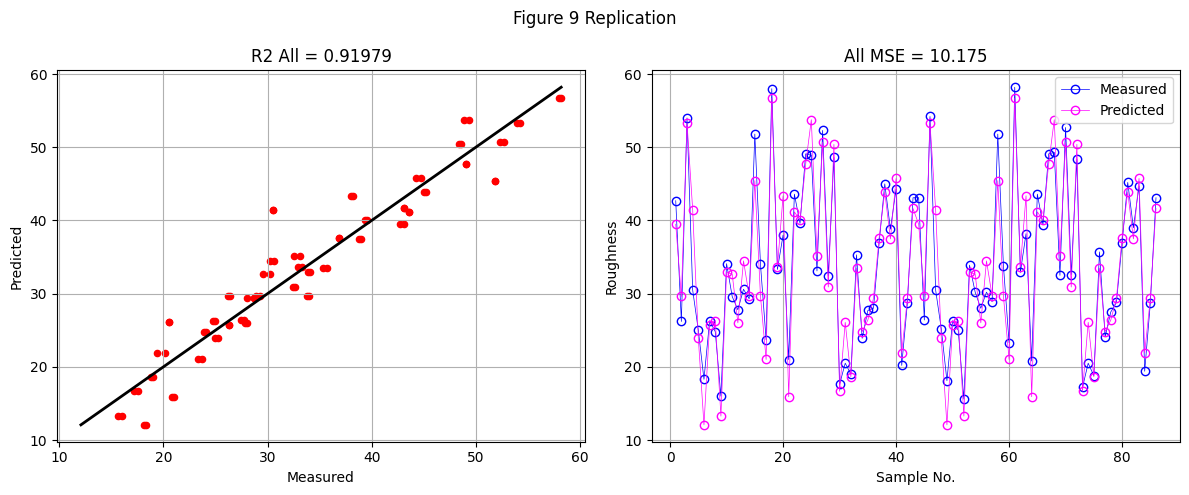

In [19]:
# --- FIGURA 9: R2 All y MSE ---
fig9, axs = plt.subplots(1, 2, figsize=(12, 5))

# R2 Plot
slope, intercept, r_value, p_value, std_err = stats.linregress(y_all_real, pred_all_real)
axs[0].scatter(y_all_real, pred_all_real, color='red', s=20, label='Data')
min_val = min(y_all_real.min(), pred_all_real.min())
max_val = max(y_all_real.max(), pred_all_real.max())
axs[0].plot([min_val, max_val], [min_val, max_val], 'k-', linewidth=2)
axs[0].set_title(f'R2 All = {r_value**2:.5f}')
axs[0].set_xlabel('Measured')
axs[0].set_ylabel('Predicted')
axs[0].grid(True)

# MSE Run Chart
mse = mean_squared_error(y_all_real, pred_all_real)
indices = np.arange(1, len(y_all_real) + 1)
axs[1].plot(indices, y_all_real, 'o-', mfc='none', mec='blue', color='blue', label='Measured', lw=0.5)
axs[1].plot(indices, pred_all_real, 'o-', mfc='none', mec='magenta', color='magenta', label='Predicted', lw=0.5)
axs[1].set_title(f'All MSE = {mse:.3f}')
axs[1].set_xlabel('Sample No.')
axs[1].set_ylabel('Roughness')
axs[1].legend()
axs[1].grid(True)

plt.suptitle('Figure 9 Replication')
plt.tight_layout()

In [17]:
print(f"R2 Global: {r_value**2}")
print(f"MSE Global: {mse}")

R2 Global: 0.9197909567907577
MSE Global: 10.17500207919814


--- REPLICACIÓN EXACTA TABLA 7 ---
Source Sum of Squares Std deviation DF F value P value
 Model        4967.93          3.36 20   22.03  0.0000
     A         198.73          0.58  1   17.62  0.0004
     B        2530.14          0.58  1  224.35  0.0000
     C         807.54          0.58  1   71.61  0.0000
     D         450.05          0.58  1   39.91  0.0000
     E         335.48          0.58  1   29.75  0.0000
   A^2           3.14          2.14  1    0.28  0.6028
    AB          12.38          0.59  1    1.10  0.3062
    AC          27.94          0.59  1    2.48  0.1298
    AD          14.99          0.59  1    1.33  0.2614
    AE          22.61          0.59  1    2.01  0.1708
   B^2          15.57          2.14  1    1.38  0.2525
    BC          11.16          0.59  1    0.99  0.3306
    BD          63.00          0.59  1    5.59  0.0274
    BE          10.01          0.59  1    0.89  0.3563
   C^2          65.93          2.14  1    5.85  0.0243
    CD          13.13         

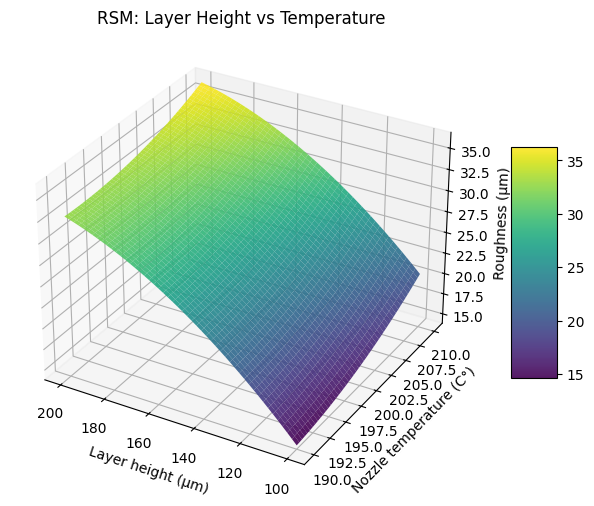

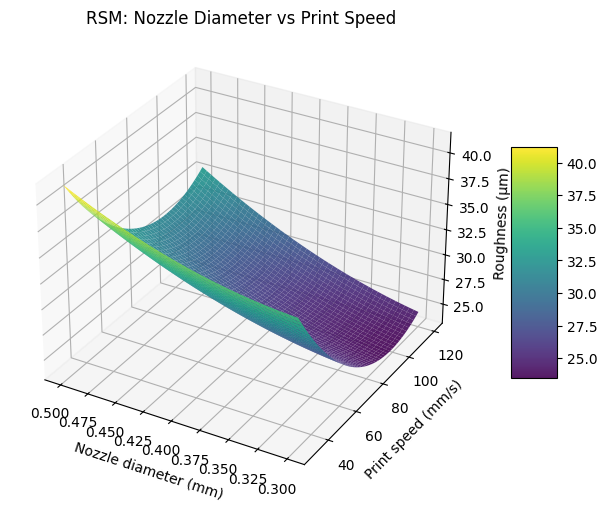

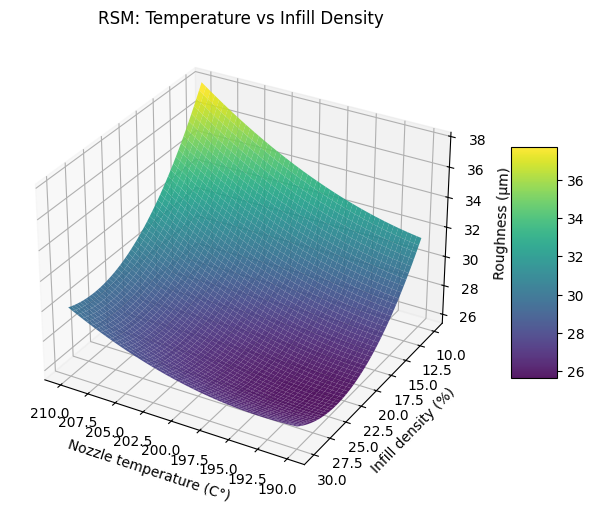

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures

# 1. CARGAR Y PREPARAR DATOS
# ---------------------------------------------------------
# Calcular la respuesta promedio (Test1 + Test2) / 2
# Nota: Usamos los 43 experimentos del diseño original (filas únicas)
# Si el CSV tiene duplicados (86 filas), el ajuste será idéntico pero 
# para pureza metodológica RSM, agrupamos por experimento.
raw_feature_names = df.columns[1:6].tolist()
df['Roughness_Avg'] = (df.iloc[:, 6] + df.iloc[:, 7]) / 2

# Agrupar para asegurar que tenemos las 43 corridas únicas del CCD
# (Si tu CSV ya tiene solo 43 filas, este paso no cambia nada)
df_rsm = df.groupby('Experiment no.').mean().reset_index()

X_raw = df_rsm.iloc[:, 1:6].values  # Temp, Layer, Speed, Diameter, Density
y = df_rsm['Roughness_Avg'].values

# 2. CODIFICACIÓN DE VARIABLES [-1, 1] (CRUCIAL para Tabla 7)
# ---------------------------------------------------------
# Centros y Deltas basados en Tabla 1 del paper
# A (Temp): 200 +/- 10
# B (Layer): 150 +/- 50
# C (Speed): 75 +/- 45
# D (Dia): 0.4 +/- 0.1
# E (Dens): 20 +/- 10

X_coded = np.zeros_like(X_raw)
X_coded[:, 0] = (X_raw[:, 0] - 200) / 10
X_coded[:, 1] = (X_raw[:, 1] - 150) / 50
X_coded[:, 2] = (X_raw[:, 2] - 75) / 45
X_coded[:, 3] = (X_raw[:, 3] - 0.4) / 0.1
X_coded[:, 4] = (X_raw[:, 4] - 20) / 10

feature_names = ["A", "B", "C", "D", "E"]

# 3. GENERAR TÉRMINOS DEL MODELO CUADRÁTICO
# ---------------------------------------------------------
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X_coded)
poly_names = poly.get_feature_names_out(feature_names)

# Ajustar Modelo OLS
model = sm.OLS(y, X_poly).fit()

# 4. CONSTRUCCIÓN EXACTA DE LA TABLA 7
# ---------------------------------------------------------
# La Tabla 7 reporta: Sum of Squares, Std Deviation (Std Error), DF, F value, P value
# Para términos individuales (1 DF), F = t^2 y SS = t^2 * MSE

mse = model.mse_resid  # Mean Squared Error (Varianza residual)
rows = []

# --- FILA DEL MODELO (GLOBAL) ---
rows.append({
    "Source": "Model",
    "Sum of Squares": model.ess,      # Explained Sum of Squares
    "Std deviation": np.sqrt(mse),    # Root MSE del modelo global
    "DF": model.df_model,
    "F value": model.fvalue,
    "P value": model.f_pvalue
})

# --- FILAS DE LOS TÉRMINOS INDIVIDUALES ---
# Iteramos sobre los términos (saltando el intercepto/constante que es el índice 0)
# poly_names[0] es "1" (bias), empezamos desde 1
for i, name in enumerate(poly_names[1:], start=1):
    # Métricas del término
    coef = model.params[i]
    std_err = model.bse[i]     # Esto es lo que el paper llama "Std deviation" para los factores
    t_value = model.tvalues[i]
    p_value = model.pvalues[i]
    
    # Cálculos ANOVA para 1 grado de libertad
    f_value = t_value ** 2
    sum_squares = f_value * mse 
    
    # Formatear nombre (Quitar espacios de PolynomialFeatures, ej: "A B" -> "AB")
    name_formatted = name.replace(" ", "")
    
    rows.append({
        "Source": name_formatted,
        "Sum of Squares": sum_squares,
        "Std deviation": std_err,
        "DF": 1,
        "F value": f_value,
        "P value": p_value
    })

# Crear DataFrame
df_table7 = pd.DataFrame(rows)

# 5. FORMATEO FINAL
# ---------------------------------------------------------
# Ordenar columnas como en el paper 
cols_order = ["Source", "Sum of Squares", "Std deviation", "DF", "F value", "P value"]
df_table7 = df_table7[cols_order]

# Formatear números para visualización limpia
pd.options.display.float_format = '{:.4f}'.format

print("--- REPLICACIÓN EXACTA TABLA 7 ---")
# Definir un diccionario de formatos
formato_columnas = {
    "Sum of Squares": "{:.2f}".format,  # 2 decimales
    "Std deviation": "{:.2f}".format,   # 2 decimales
    "DF": "{:.0f}".format,              # 0 decimales
    "F value": "{:.2f}".format,         # 2 decimales
    "P value": "{:.4f}".format          # 4 decimales
}

# Imprimir aplicando los formatos
print(df_table7.to_string(index=False, formatters=formato_columnas))

# Verificación rápida de valores clave del paper:
# Model F-value: ~22.15
# P-value Model: 0.0001
# B (Layer) P-value: 0.0001
# BD Interaction P-value: ~0.0266

# ==============================================================================
# PARTE 2: VISUALIZACIÓN 3D (Usando Unidades Reales para los Ejes)
# ==============================================================================

# Entrenar un modelo auxiliar con datos CRUDOS solo para graficar (visualmente idéntico)
poly_raw = PolynomialFeatures(degree=2, include_bias=True)
X_poly_raw = poly_raw.fit_transform(X_raw)
model_raw = sm.OLS(y, X_poly_raw).fit()

def plot_3d_surface(model, poly, feature_names, x_col, y_col, fixed_values, title):
    # Crear rangos reales para los ejes
    col_idx_x = feature_names.index(x_col)
    col_idx_y = feature_names.index(y_col)
    
    # Extraer min y max de los datos originales
    x_min, x_max = X_raw[:, col_idx_x].min(), X_raw[:, col_idx_x].max()
    y_min, y_max = X_raw[:, col_idx_y].min(), X_raw[:, col_idx_y].max()
    
    x_range = np.linspace(x_min, x_max, 50)
    y_range = np.linspace(y_min, y_max, 50)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    
    # Matriz base con valores fijos (medias)
    input_data = np.zeros((X_grid.size, 5))

    for i in range(5):
        input_data[:, i] = fixed_values[i]
    
    # Insertar variables del gráfico
    input_data[:, col_idx_x] = X_grid.ravel()
    input_data[:, col_idx_y] = Y_grid.ravel()
    
    # Predecir
    input_poly = poly.transform(input_data)
    Z = model.predict(input_poly).reshape(X_grid.shape)
    
    # Plot
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel('Roughness (µm)')
    ax.set_title(title)
    fig.colorbar(surf, shrink=0.5, aspect=5)
    
    # Invertir ejes según lógica del usuario
    if x_col in ["Layer height (μm)", "Nozzle diameter (mm)", "Nozzle temperature (C°)"]:
        ax.invert_xaxis()
    if y_col in ["Infill density (%)"]:
        ax.invert_yaxis()
        
    plt.show()

# Medias de los datos crudos para fijar las otras variables
means_raw = X_raw.mean(axis=0)

# Gráfico 1: Temp vs Layer
plot_3d_surface(model_raw, poly_raw, raw_feature_names, 
                x_col="Layer height (μm)", y_col="Nozzle temperature (C°)", fixed_values=means_raw,
                title="RSM: Layer Height vs Temperature")

# Gráfico 2: Speed vs Diameter
plot_3d_surface(model_raw, poly_raw, raw_feature_names,
                x_col="Nozzle diameter (mm)", y_col="Print speed (mm/s)", fixed_values=means_raw,
                title="RSM: Nozzle Diameter vs Print Speed")

# Gráfico 3: Temp vs Infill
plot_3d_surface(model_raw, poly_raw, raw_feature_names,
                x_col="Nozzle temperature (C°)", y_col="Infill density (%)", fixed_values=means_raw,
                title="RSM: Temperature vs Infill Density")